# Section 2 — ETL 

In [27]:
!ls /kaggle/input/notebooks/mirakh/01-load-validate-ipynb/

class_distribution.png	df_raw.csv	    __results___files
custom.css		__notebook__.ipynb  __results__.html
deep_exploration.png	__output__.json


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings, gc
warnings.filterwarnings('ignore')

In [31]:
OUTPUT_PATH = '/kaggle/working/'

# ── E : Extract — Load df_raw from Section 1

In [32]:
df = pd.read_csv('/kaggle/input/notebooks/mirakh/01-load-validate-ipynb/df_raw.csv', low_memory=False)
df.columns = df.columns.str.strip()

print(f'Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns')

Loaded : 2,830,743 rows × 80 columns


# ── T : Transform — Preprocessing

── T1 : Preprocessing — Step 1 : Remove useless columns
source_file       → traceability column we added, useless for ML
Fwd Header Length.1 → exact duplicate of Fwd Header Length

In [33]:
cols_to_drop = ['source_file', 'Fwd Header Length.1']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df.drop(columns=cols_to_drop, inplace=True)

print(f' Columns removed : {cols_to_drop}')
print(f' Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

 Columns removed : ['source_file', 'Fwd Header Length.1']
 Shape : 2,830,743 rows × 78 columns


── T1 : Preprocessing — Step 2 : Remove duplicate rows -> Keeping duplicates = model learns same examples multiple times = overfitting

In [34]:
before = df.shape[0]
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
after = df.shape[0]

print(f'Duplicates removed : {before - after:,}')
print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

Duplicates removed : 308,381
Shape : 2,522,362 rows × 78 columns


In [35]:
print('=' * 50)
print('   Duplications Verifications')
print('=' * 50)

remaining = df.duplicated().sum()
print(f'\nDuplications rest : {remaining}')

if remaining == 0:
    print('OK — Noo duplications')
else:
    print(f'ATTENTION — {remaining} still duplicates !')
    print('\nExemples de doublons restants :')
    dup_rows = df[df.duplicated(keep=False)]
    print(dup_rows.head(4)[['Destination Port', 
                             'Flow Duration',
                             'Total Fwd Packets', 
                             'Label']].to_string())

   Duplications Verifications

Duplications rest : 0
OK — Noo duplications


── T1 : Preprocessing — Step 3 : Fix infinite and missing values
Flow Bytes/s and Flow Packets/s contain inf (division by zero)
inf → NaN → replaced by median

In [36]:
total_inf = np.isinf(df.select_dtypes(include='number')).sum().sum()
total_nan = df.isnull().sum().sum()

print(f'Total inf in df : {total_inf}')
print(f'Total NaN in df : {total_nan}')
print(f'Actual Shape    : {df.shape}')

Total inf in df : 2775
Total NaN in df : 353
Actual Shape    : (2522362, 78)


**Inf Explaratioin**

In [37]:
print('=' * 60)
print('   DEEP EXPLORATION — INFINITE VALUES')
print('=' * 60)

# 1. Quelles colonnes ont des inf
inf_per_col = np.isinf(df.select_dtypes(include='number')).sum()
inf_per_col = inf_per_col[inf_per_col > 0]

print(f'\nColumns with inf values:')
for col, count in inf_per_col.items():
    pct = count / len(df) * 100
    print(f'   {col:<25} → {count:,} inf  ({pct:.4f}%)')

# 2. Positif vs Negatif
print(f'\nType of infinite :')
for col in inf_per_col.index:
    pos = (df[col] == np.inf).sum()
    neg = (df[col] == -np.inf).sum()
    print(f'   {col:<25} → +inf : {pos:,}   -inf : {neg:,}')

# 3. Cause racine — Flow Duration = 0
print(f'\nCause — Flow Duration = 0 :')
zero_dur = df[df['Flow Duration'] == 0]
print(f'   rows with Durations = 0     : {len(zero_dur):,}')
print(f'   Inf in these rows          : {np.isinf(zero_dur["Flow Bytes/s"]).sum():,}')
print(f'   Formule : bytes / 0 = inf    → CONFIRME')

   DEEP EXPLORATION — INFINITE VALUES

Columns with inf values:
   Flow Bytes/s              → 1,211 inf  (0.0480%)
   Flow Packets/s            → 1,564 inf  (0.0620%)

Type of infinite :
   Flow Bytes/s              → +inf : 1,211   -inf : 0
   Flow Packets/s            → +inf : 1,564   -inf : 0

Cause — Flow Duration = 0 :
   rows with Durations = 0     : 1,564
   Inf in these rows          : 1,211
   Formule : bytes / 0 = inf    → CONFIRME


**NAN Exploration**

In [38]:
print('=' * 60)
print('   DEEP EXPLORATION — NaN VALUES')
print('=' * 60)

nan_cols = df.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
print(f'\nColumns with NaN :')
for col, count in nan_cols.items():
    pct = count / len(df) * 100
    print(f'   {col:<25} → {count:,} NaN  ({pct:.4f}%)')


   DEEP EXPLORATION — NaN VALUES

Columns with NaN :
   Flow Bytes/s              → 353 NaN  (0.0140%)


In [39]:
# Step 1 : inf → NaN
inf_before = np.isinf(df.select_dtypes(include='number')).sum().sum()
df.replace([np.inf, -np.inf], np.nan, inplace=True)
print(f'Infinite values replaced : {inf_before:,}')

Infinite values replaced : 2,775


In [40]:
# 1. Quelles colonnes ont des inf
inf_per_col = np.isinf(df.select_dtypes(include='number')).sum()
inf_per_col = inf_per_col[inf_per_col > 0]
print("No columns have inf values")

No columns have inf values


In [41]:
# Step 2 : NaN → median
nan_before = df.isnull().sum().sum()
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f' {col} → filled with median ({median_val:.4f})')

 Flow Bytes/s → filled with median (3715.0379)
 Flow Packets/s → filled with median (69.7422)


In [42]:
print('=' * 60)
print('   DEEP EXPLORATION — NaN VALUES')
print('=' * 60)

nan_cols = df.isnull().sum()
nan_cols = nan_cols[nan_cols > 0]
print(f'\nColumns with NaN :')
for col, count in nan_cols.items():
    pct = count / len(df) * 100
    print(f'   {col:<25} → {count:,} NaN  ({pct:.4f}%)')


   DEEP EXPLORATION — NaN VALUES

Columns with NaN :


In [43]:
print(f'Missing values fixed : {nan_before:,} → {df.isnull().sum().sum()}')

Missing values fixed : 3,128 → 0


── T1 : Preprocessing — Step 4 : Remove constant columns
A constant column has only 1 unique value across all rows
It gives ZERO information to the ML model

In [44]:
constant_cols = [col for col in df.columns
                 if df[col].nunique() <= 1 and col != 'Label']

print(f'Constant columns found : {len(constant_cols)}')
for c in constant_cols:
    print(f'   → {c} = {df[c].unique()}')

df.drop(columns=constant_cols, inplace=True)

print(f'Shape : {df.shape[0]:,} rows × {df.shape[1]} columns')

Constant columns found : 8
   → Bwd PSH Flags = [0]
   → Bwd URG Flags = [0]
   → Fwd Avg Bytes/Bulk = [0]
   → Fwd Avg Packets/Bulk = [0]
   → Fwd Avg Bulk Rate = [0]
   → Bwd Avg Bytes/Bulk = [0]
   → Bwd Avg Packets/Bulk = [0]
   → Bwd Avg Bulk Rate = [0]
Shape : 2,522,362 rows × 70 columns


── T2 : Feature Engineering — Step 1 : Encode Label column
ML models only understand numbers, not text
BENIGN → 0
Any attack → 1  (binary classification)
Also create multiclass encoding for later use

In [46]:
# Binary encoding
df['Label_binary'] = (df['Label'] != 'BENIGN').astype(int)

In [47]:
df[['Label', 'Label_binary']].head(10)

,Label,Label_binary
0,BENIGN,0
1,BENIGN,0
2,BENIGN,0
3,BENIGN,0
4,BENIGN,0
5,BENIGN,0
6,BENIGN,0
7,BENIGN,0
8,BENIGN,0
9,BENIGN,0


In [48]:
print('Label distribution :')

for label in sorted(df['Label'].unique()):
    count = (df['Label'] == label).sum()
    print(f'   {label:<35} ({count:,} rows)')

print(f'\nLabel_binary : 0={(df["Label_binary"]==0).sum():,} | 1={(df["Label_binary"]==1).sum():,}')

Label distribution :
   BENIGN                              (2,096,484 rows)
   Bot                                 (1,953 rows)
   DDoS                                (128,016 rows)
   DoS GoldenEye                       (10,286 rows)
   DoS Hulk                            (172,849 rows)
   DoS Slowhttptest                    (5,228 rows)
   DoS slowloris                       (5,385 rows)
   FTP-Patator                         (5,933 rows)
   Heartbleed                          (11 rows)
   Infiltration                        (36 rows)
   PortScan                            (90,819 rows)
   SSH-Patator                         (3,219 rows)
   Web Attack � Brute Force            (1,470 rows)
   Web Attack � Sql Injection          (21 rows)
   Web Attack � XSS                    (652 rows)

Label_binary : 0=2,096,484 | 1=425,878


 ── T2 : Feature Engineering — Step 2 : Normalize features
Problem : columns have very different scales
Flow Duration → 0 to 120,000,000
Destination Port → 0 to 65,535
ML model treats large numbers as more important → wrong !
Solution : StandardScaler → everything between -3 and +3

In [49]:
exclude = ['Label', 'Label_binary']
feature_cols = [c for c in df.select_dtypes(include='number').columns
                if c not in exclude]

scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

print(f'Normalization done')
print(f'   Mean : {df[feature_cols].mean().mean():.6f}  (≈ 0)')
print(f'   Std  : {df[feature_cols].std().mean():.6f}  (≈ 1)')

# ADD THIS — save scaler for Section 3
import joblib
joblib.dump(scaler, OUTPUT_PATH + 'scaler.pkl')
print(f'Scaler saved → scaler.pkl')

Normalization done
   Mean : 0.000000  (≈ 0)
   Std  : 1.000000  (≈ 1)
Scaler saved → scaler.pkl


# Visualization Before vs After ET# 

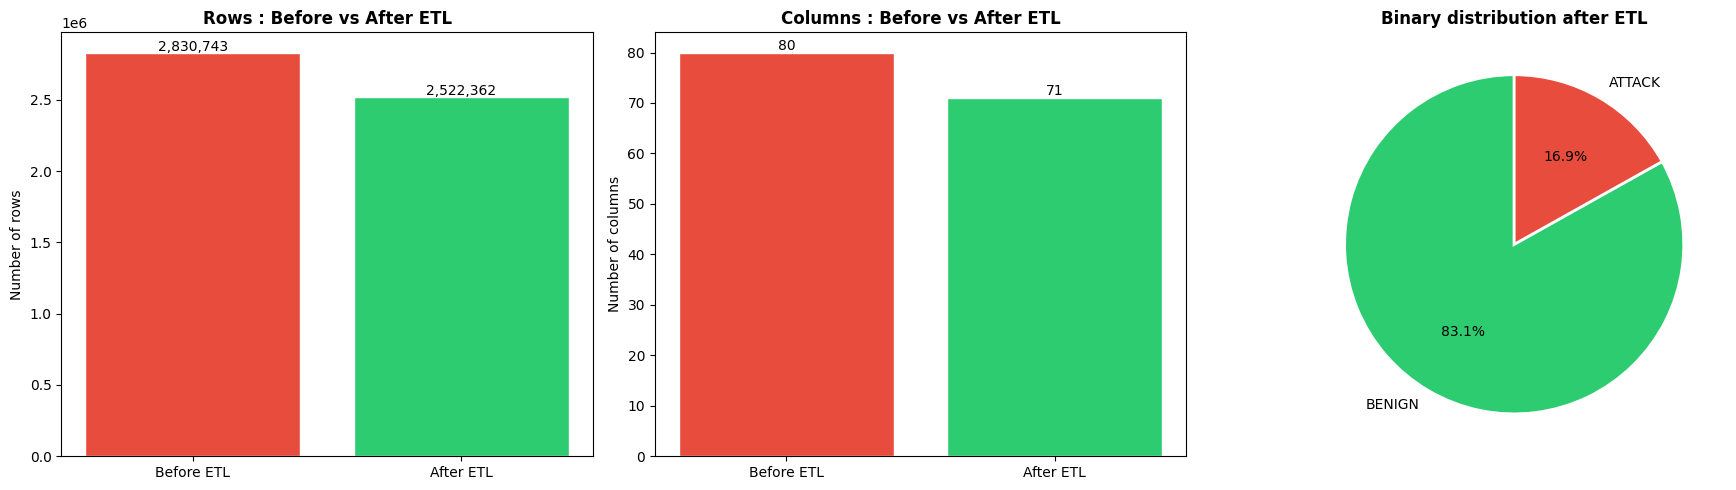

Graph saved : etl_comparison.png


In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 : Rows before vs after
categories = ['Before ETL', 'After ETL']
values = [2830743, df.shape[0]]
axes[0].bar(categories, values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Rows : Before vs After ETL', fontweight='bold')
axes[0].set_ylabel('Number of rows')
for i, v in enumerate(values):
    axes[0].text(i, v + 10000, f'{v:,}', ha='center', fontsize=10)

# Plot 2 : Columns before vs after
values2 = [80, df.shape[1]]
axes[1].bar(categories, values2, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[1].set_title('Columns : Before vs After ETL', fontweight='bold')
axes[1].set_ylabel('Number of columns')
for i, v in enumerate(values2):
    axes[1].text(i, v + 0.5, f'{v}', ha='center', fontsize=10)

# Plot 3 : Class distribution after ETL
binary_counts = df['Label_binary'].value_counts()
binary_counts.index = ['BENIGN', 'ATTACK']
colors = ['#2ecc71', '#e74c3c']
binary_counts.plot(kind='pie', ax=axes[2], autopct='%1.1f%%', colors=colors,
                   startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[2].set_title('Binary distribution after ETL', fontweight='bold')
axes[2].set_ylabel('')

plt.tight_layout()
plt.savefig(OUTPUT_PATH + 'etl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Graph saved : etl_comparison.png')

# Visualization : Multiclass distribution# 

Out of the range of the project.

# Final verification# 

In [25]:
print('=' * 55)
print('   FINAL VERIFICATION AFTER ETL')
print('=' * 55)
print(f'\nFinal shape     : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Infinite values : {np.isinf(df.select_dtypes(include="number")).sum().sum()}')
print(f'Missing values  : {df.isnull().sum().sum()}')
print(f'Duplicates      : {df.duplicated().sum()}')
print(f'Constant cols   : {sum(df[c].nunique() <= 1 for c in df.columns)}')

print(f'\nBefore ETL vs After ETL :')
print(f'   Rows    : 2,830,743  ->  {df.shape[0]:,}')
print(f'   Columns : 80         ->  {df.shape[1]}')

print(f'\nLabel_binary distribution :')
print(f'   BENIGN (0) : {(df["Label_binary"]==0).sum():,}')
print(f'   ATTACK (1) : {(df["Label_binary"]==1).sum():,}')
ratio = (df["Label_binary"]==0).sum() / (df["Label_binary"]==1).sum()
print(f'   Ratio       : {ratio:.1f}x')
print('=' * 55)

   FINAL VERIFICATION AFTER ETL

Final shape     : 2,522,362 rows x 71 columns
Infinite values : 0
Missing values  : 0
Duplicates      : 6
Constant cols   : 0

Before ETL vs After ETL :
   Rows    : 2,830,743  ->  2,522,362
   Columns : 80         ->  71

Label_binary distribution :
   BENIGN (0) : 2,096,484
   ATTACK (1) : 425,878
   Ratio       : 4.9x


# — L : Load — Save df_clean.csv

In [51]:
save_path = OUTPUT_PATH + 'df_clean.csv'
df.to_csv(save_path, index=False)

gc.collect()

print(f'Clean dataset saved : {save_path}')
print(f'   -> {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nSection 2 completed -----> Section 3 : ML Modeling')

Clean dataset saved : /kaggle/working/df_clean.csv
   -> 2,522,362 rows x 71 columns

Section 2 completed -----> Section 3 : ML Modeling
